# 29 — Gateway Prediction Percentages (Helpdesk)

Given a **gateway activity**, collect every test prefix that ends at that activity and ask the model what it predicts next. Report:

- **Argmax distribution** — for how many prefixes each activity was the top-1 prediction (% of prefixes).
- **Mean softmax** — the average probability the model assigned to each activity across those prefixes.
- **Mean top-1 confidence** — how sure the model was on average.

The decoder softmax is the point-estimate next-step distribution (dropout disabled). Use notebook 22 for a decision-tree surrogate view.

## 1. Setup

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
src_path = str(_current / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.interpretability.utils.tensor_decoder import TensorDecoder
from src.interpretability.perturbation_methods.revised_plus.revised_plus import RevisedPlusModelPredictor

# --- Dataset ---
data_path = _current / 'encoded_data' / 'test_philipp' / 'helpdesk_all_5_test.pkl'
dataset = torch.load(data_path, weights_only=False)

sample = dataset[0]
n_cat = len(sample[0])
n_num = len(sample[1])
seq_len = sample[0][0].shape[0]
print(f'Dataset: {len(dataset)} sequences, {n_cat} cat, {n_num} num, seq_len={seq_len}')

# --- Model (same as notebook 22) ---
from src.interpretability.config.helpdesk_config import CONFIG
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()

decoder = TensorDecoder(dataset)

ACTIVITY_FEATURE = 'Activity'
activity_idx_to_label = decoder.idx_to_label[ACTIVITY_FEATURE]
max_idx = max(activity_idx_to_label.keys())
activity_names = [activity_idx_to_label.get(i, f'<unk_{i}>') for i in range(max_idx + 1)]
eos_idx = next(i for i, name in enumerate(activity_names) if name == 'EOS')

predictor = RevisedPlusModelPredictor(model, suffix_step=0, activity_feature=ACTIVITY_FEATURE)

ACT_IDX = decoder.cat_features.index(ACTIVITY_FEATURE)
print(f'Activity vocabulary ({len(activity_names)}), EOS={eos_idx}, ACT_IDX={ACT_IDX}')

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:163: DeprecationWarning: module 'sre_parse' is deprecated
  import sre_parse
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:164: DeprecationWarning: module 'sre_constants' is deprecated
  import sre_constants


Dataset: 6077 sequences, 12 cat, 4 num, seq_len=18
Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '12

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

## 2. Choose the gateway

Set `GATEWAY_ACTIVITY` to the activity whose outgoing decision you want to inspect. Observed gateways in Helpdesk include: `Assign seriousness`, `Take in charge ticket`, `Resolve ticket`, `Wait`, `Insert ticket`, `Require upgrade`.

In [3]:
GATEWAY_ACTIVITY = 'Assign seriousness'  # <-- change this
TOP_K = 15                                # how many entries to show in the ranking

## 3. Collect test prefixes ending at this activity

In [4]:
# Unique cases: longest trace per case_id (same pattern as notebook 22).
cases = {}
for i in range(len(dataset)):
    cat_t, num_t, case_id = dataset[i]
    trace_len = int((cat_t[0] != 0).sum().item())
    if case_id not in cases or trace_len > cases[case_id][1]:
        cases[case_id] = (i, trace_len)

cat_list = []
num_list = []
actual_next = []

for case_id, (ds_idx, trace_len) in cases.items():
    cat_full, num_full, _ = dataset[ds_idx]
    src_start = seq_len - trace_len
    acts = cat_full[ACT_IDX][src_start:src_start + trace_len]

    useful_len = trace_len
    for j in range(trace_len - 1, -1, -1):
        if acts[j].item() == eos_idx:
            useful_len = j
        else:
            break

    for k in range(useful_len - 1):
        if activity_names[acts[k].item()] != GATEWAY_ACTIVITY:
            continue
        prefix_len = k + 1
        pad_len = seq_len - prefix_len

        cat_prefix = []
        for c in cat_full:
            t = torch.zeros_like(c)
            t[pad_len:] = c[src_start:src_start + prefix_len]
            cat_prefix.append(t)
        num_prefix = []
        for n in num_full:
            t = torch.zeros_like(n)
            t[pad_len:] = n[src_start:src_start + prefix_len]
            num_prefix.append(t)

        cat_list.append(cat_prefix)
        num_list.append(num_prefix)
        actual_next.append(activity_names[acts[k + 1].item()])

N = len(cat_list)
print(f"Gateway '{GATEWAY_ACTIVITY}': {N} test prefixes found.")
assert N > 0, f'No test prefixes end at activity {GATEWAY_ACTIVITY!r}'

Gateway 'Assign seriousness': 995 test prefixes found.


## 4. Run the model (batched)

In [5]:
cat_batch = [torch.stack([cat_list[i][ci] for i in range(N)]) for ci in range(n_cat)]
num_stacked = torch.stack([torch.stack(num_list[i], dim=-1) for i in range(N)])

preds, probs = predictor.predict_batch(cat_batch, num_stacked, batch_size=128)
# preds: [N] argmax class indices; probs: [N, n_classes] softmax probabilities
print('preds shape:', preds.shape, '| probs shape:', probs.shape)

preds shape: (995,) | probs shape: (995, 16)


## 5. Percentages

Two complementary views:

- **Argmax %** — fraction of the N prefixes where the model's top-1 prediction was this activity.
- **Mean softmax %** — average probability the model put on this activity across all N prefixes (a probabilistic fingerprint of the gateway).
- **Actual %** — what actually happened next in the log (for comparison).

In [6]:
n_classes = probs.shape[1]
class_names = [activity_names[i] if i < len(activity_names) else f'<cls_{i}>' for i in range(n_classes)]

# 1. Argmax distribution
argmax_counts = np.bincount(preds, minlength=n_classes)
argmax_pct = argmax_counts / N * 100

# 2. Mean softmax
mean_probs_pct = probs.mean(axis=0) * 100

# 3. Actual next-activity distribution
actual_counts = {a: 0 for a in class_names}
for a in actual_next:
    actual_counts[a] = actual_counts.get(a, 0) + 1
actual_pct = np.array([actual_counts.get(n, 0) for n in class_names]) / N * 100

# 4. Mean top-1 confidence
mean_top1 = probs.max(axis=1).mean() * 100

df = pd.DataFrame({
    'Activity': class_names,
    'Argmax %': argmax_pct,
    'Mean softmax %': mean_probs_pct,
    'Actual %': actual_pct,
})
df = df[df[['Argmax %', 'Mean softmax %', 'Actual %']].sum(axis=1) > 0]
df = df.sort_values('Mean softmax %', ascending=False).reset_index(drop=True)

print(f"Gateway: {GATEWAY_ACTIVITY}")
print(f"N prefixes: {N}")
print(f"Mean top-1 confidence: {mean_top1:.1f}%\n")

with pd.option_context('display.float_format', '{:.2f}'.format):
    display(df.head(TOP_K))

Gateway: Assign seriousness
N prefixes: 995
Mean top-1 confidence: 50.1%



,Activity,Argmax %,Mean softmax %,Actual %
0,Take in charge ticket,55.28,46.84,84.12
1,Resolve ticket,44.72,31.48,5.03
2,Wait,0.00,13.86,1.11
3,Assign seriousness,0.00,2.34,9.65
4,Closed,0.00,2.00,0.00
5,EOS,0.00,1.94,0.00
6,Require upgrade,0.00,0.81,0.10
7,Create SW anomaly,0.00,0.43,0.00
8,Resolve SW anomaly,0.00,0.07,0.00
9,DUPLICATE,0.00,0.04,0.00


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.


DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.


DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-BoldItalic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335


DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymBol.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335


...

DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/NotoSansSharada-Regular.ttf', name='Noto Sans Sharada', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/Khmer Sangam MN.ttf', name='Khmer Sangam MN', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/NotoSansAvestan-Regular.ttf', name='Noto Sans Avestan', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Courier.ttc', name='Courier', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0 to DejaVu Sans ('/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf') with score of 0.050000.


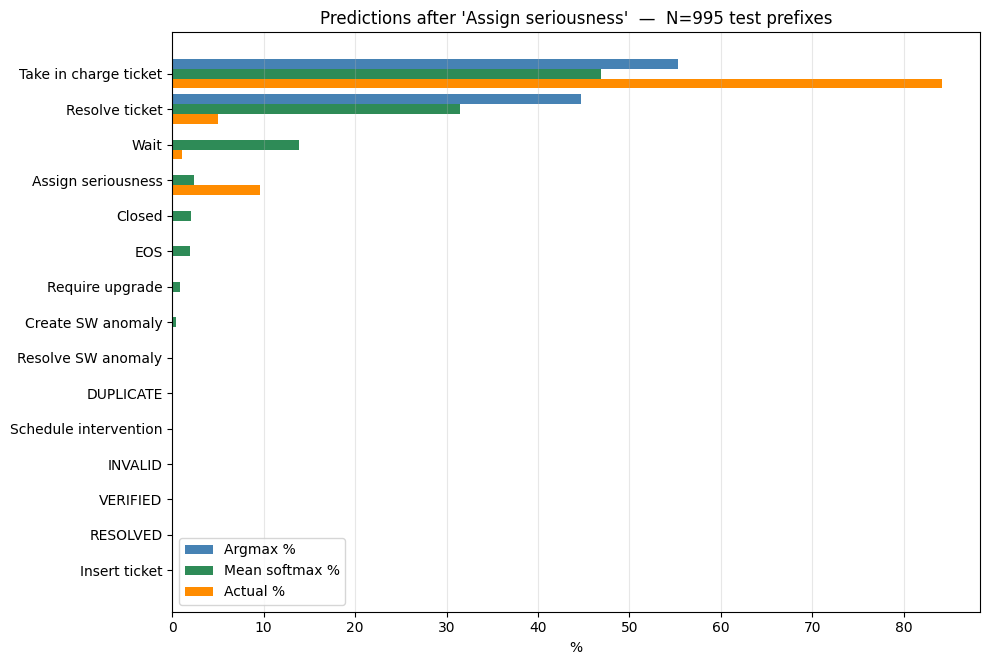

In [7]:
top = df.head(TOP_K).iloc[::-1]
y = np.arange(len(top))
h = 0.28

fig, ax = plt.subplots(figsize=(10, max(3.5, len(top) * 0.45)))
ax.barh(y + h, top['Argmax %'], h, label='Argmax %', color='steelblue')
ax.barh(y,     top['Mean softmax %'], h, label='Mean softmax %', color='seagreen')
ax.barh(y - h, top['Actual %'], h, label='Actual %', color='darkorange')
ax.set_yticks(y)
ax.set_yticklabels(top['Activity'])
ax.set_xlabel('%')
ax.set_title(f"Predictions after '{GATEWAY_ACTIVITY}'  —  N={N} test prefixes")
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Plain text list

In [8]:
print(f"Argmax predictions after '{GATEWAY_ACTIVITY}' (N={N}):")
for _, r in df.iterrows():
    if r['Argmax %'] > 0:
        print(f"  {r['Activity']:<32s}  {r['Argmax %']:6.2f}%")

print(f"\nMean softmax probability after '{GATEWAY_ACTIVITY}' (N={N}):")
for _, r in df.iterrows():
    if r['Mean softmax %'] >= 0.1:
        print(f"  {r['Activity']:<32s}  {r['Mean softmax %']:6.2f}%")

Argmax predictions after 'Assign seriousness' (N=995):
  Take in charge ticket              55.28%
  Resolve ticket                     44.72%

Mean softmax probability after 'Assign seriousness' (N=995):
  Take in charge ticket              46.84%
  Resolve ticket                     31.48%
  Wait                               13.86%
  Assign seriousness                  2.34%
  Closed                              2.00%
  EOS                                 1.94%
  Require upgrade                     0.81%
  Create SW anomaly                   0.43%
